
# Hand-coded solution reachability: train exactly two models

This notebook answers one precise question:

> The PROCESS and OUTCOME hand-coded Transformers already achieve 100% accuracy.  
> If we keep **each exact hand-coded architecture**, randomize its weights, and train it with its natural supervision, does gradient descent recover a 100%-accurate solution?

We train exactly **two models**:

| Trainable model | Architecture | Training target |
|---|---|---|
| `process_random_base` | exact `HandcodedProcessTransformer` layout | PROCESS / trace continuation |
| `outcome_random_base` | exact `HandcodedOutcomeTransformer` layout | OUTCOME-only continuation |

The two fixed hand-coded models are **references only** and are never optimized.

So the experiment is

\[
\boxed{
\text{2 fixed 100\% references}
+
\text{2 randomly initialized trainable models}
}
\]

with only the latter two undergoing gradient updates.

This is a **reachability experiment**, not yet an architecture-matched causal comparison between PROCESS and OUTCOME.



## 1. Imports and configuration

This notebook uses the `handcoded` package: circuit generator, tokenizer, fixed executors, training loop.


In [1]:

import copy
import importlib
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "handcoded").is_dir() else Path.cwd().parent
if not (ROOT / "handcoded").is_dir():
    ROOT = Path.cwd().resolve()
    while ROOT != ROOT.parent and not (ROOT / "handcoded").is_dir():
        ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import handcoded
importlib.reload(handcoded)

from handcoded import (
    BATCH_SIZE,
    BATCH_SEED,
    DATA_SEED,
    DEPTH,
    LR,
    MODEL_SEED,
    TEST_SEED,
    TEST_SIZE,
    TRAIN_SIZE,
    HandcodedOutcomeTransformer,
    HandcodedProcessTransformer,
    encode_dataset,
    free_run_metrics,
    generate,
    language_model_loss,
    make_batch_schedule,
    make_checkpoints,
    make_circuit_prompts,
    make_circuits,
    make_generation_evaluation,
    make_random_trainable_copy,
    make_tokenizer,
    train_one_model,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Main experiment settings.
N_TRAIN = TRAIN_SIZE
N_TEST = TEST_SIZE
STEPS = 2_000
LOSS_EVAL_SIZE = 64
CHECKPOINTS = make_checkpoints(STEPS, animation_checkpoints=40)

print("device:", DEVICE)
print("depth:", DEPTH)
print("train examples:", N_TRAIN)
print("test examples:", N_TEST)
print("steps:", STEPS)
print("loss eval examples:", LOSS_EVAL_SIZE)


device: cuda
depth: 4
train examples: 20000
test examples: 1000
steps: 2000
loss eval examples: 64


/home/hariguru/aayus/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Build the same dataset for both models

A circuit is

$$
s_t=\Phi(s_{t-1},g_t),\qquad t=1,\ldots,D.
$$

Both models receive the same prompt

```text
S0 g1 g2 ... gD <SEP>
```

but their supervised continuations differ.

PROCESS:

```text
g1 S1 g2 S2 ... gD SD <COLON> SD <EOS>
```

OUTCOME:

```text
<COLON> SD <EOS>
```

The underlying circuits, train/test split, and minibatch schedule are shared.


In [2]:

tokenizer = make_tokenizer()

train_circuits = make_circuits(N_TRAIN, DATA_SEED, DEPTH)
test_circuits = make_circuits(N_TEST, TEST_SEED, DEPTH)
example = test_circuits[0]

training_data = {
    mode: encode_dataset(train_circuits, tokenizer, mode).to(DEVICE)
    for mode in ("process", "outcome")
}

# Held-out teacher-forced loss uses the test split. The training helper samples
# a deterministic prefix of this batch at checkpoints for speed.
test_loss_data = {
    mode: encode_dataset(test_circuits, tokenizer, mode).to(DEVICE)
    for mode in ("process", "outcome")
}

batch_schedule = make_batch_schedule(
    N_TRAIN, STEPS, BATCH_SIZE, BATCH_SEED
)

train_eval = make_generation_evaluation(
    train_circuits[:min(300, len(train_circuits))],
    tokenizer,
    DEVICE,
)

test_eval = make_generation_evaluation(
    test_circuits,
    tokenizer,
    DEVICE,
)

circuit_prompts = make_circuit_prompts(
    example.gates,
    tokenizer,
    DEVICE,
)

print("Prompt :", tokenizer.decode(tokenizer.prompt(example)))
print("PROCESS:", tokenizer.decode(tokenizer.continuation(example, "process")))
print("OUTCOME:", tokenizer.decode(tokenizer.continuation(example, "outcome")))


Prompt : S1011 s02 c31 c31 t302 <SEP>
PROCESS: s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>
OUTCOME: <COLON> S1001 <EOS>



## 3. Fixed hand-coded references

These two models encode perfect algorithms directly in their weights.

### PROCESS reference

`HandcodedProcessTransformer`

- one causal attention/MLP block,
- four fixed attention heads,
- one ReLU unit for each `(state, gate)` pair,
- autoregressive reuse of the same block to emit intermediate states.

### OUTCOME reference

`HandcodedOutcomeTransformer`

- one causal attention/MLP block per circuit step,
- two attention heads per block,
- intermediate states remain internal to the residual stream,
- only the final answer is emitted.

They are not trained below. They establish that a 100% solution exists in each architecture class.


In [3]:

process_reference = HandcodedProcessTransformer(
    tokenizer, DEPTH
).to(DEVICE)

outcome_reference = HandcodedOutcomeTransformer(
    tokenizer, DEPTH
).to(DEVICE)

reference_rows = []

for name, model, mode in [
    ("Fixed PROCESS", process_reference, "process"),
    ("Fixed OUTCOME", outcome_reference, "outcome"),
]:
    metrics = free_run_metrics(model, test_eval, tokenizer, mode)
    reference_rows.append({
        "model": name,
        "mode": mode,
        "answer_accuracy": metrics["final_answer"],
        "exact_continuation": metrics["exact_continuation"],
    })

pd.DataFrame(reference_rows)


,model,mode,answer_accuracy,exact_continuation
0,Fixed PROCESS,process,1.0,1.0
1,Fixed OUTCOME,outcome,1.0,1.0



Expected result:

$$
\operatorname{Acc}(\theta^\star_{\rm P})
=
\operatorname{Acc}(\theta^\star_{\rm O})
=
100\%.
$$

That is the realizability baseline.



## 4. Turn each exact hand-coded architecture into a random trainable model

This is the crucial correction.

We do **not** call `build_random_learned_model()`. That would create an unrelated ordinary one-layer Transformer.

Instead, `make_random_trainable_copy()`:

1. deep-copies the exact hand-coded model,
2. converts its stored weight buffers into `nn.Parameter`s,
3. randomly initializes those tensors.

Therefore the computational graph and tensor layout are inherited directly from the corresponding constructive model.


In [4]:

process_random_base = make_random_trainable_copy(
    process_reference,
    seed=MODEL_SEED,
    init_std=0.02,
    device=DEVICE,
)

outcome_random_base = make_random_trainable_copy(
    outcome_reference,
    seed=MODEL_SEED,
    init_std=0.02,
    device=DEVICE,
)

def trainable_params(model):
    return sum(p.numel() for p in model.parameters())

def stored_scalars(model):
    return sum(t.numel() for t in model.state_dict().values())

summary = pd.DataFrame([
    {
        "model": "Fixed PROCESS reference",
        "trainable_parameters": trainable_params(process_reference),
        "stored_scalars": stored_scalars(process_reference),
        "max_length": process_reference.max_length,
    },
    {
        "model": "Random trainable PROCESS architecture",
        "trainable_parameters": trainable_params(process_random_base),
        "stored_scalars": stored_scalars(process_random_base),
        "max_length": process_random_base.max_length,
    },
    {
        "model": "Fixed OUTCOME reference",
        "trainable_parameters": trainable_params(outcome_reference),
        "stored_scalars": stored_scalars(outcome_reference),
        "max_length": outcome_reference.max_length,
    },
    {
        "model": "Random trainable OUTCOME architecture",
        "trainable_parameters": trainable_params(outcome_random_base),
        "stored_scalars": stored_scalars(outcome_random_base),
        "max_length": outcome_random_base.max_length,
    },
])

summary


,model,trainable_parameters,stored_scalars,max_length
0,Fixed PROCESS reference,0,441664,16
1,Random trainable PROCESS architecture,441664,441664,16
2,Fixed OUTCOME reference,0,3588000,8
3,Random trainable OUTCOME architecture,3588000,3588000,8



A fixed reference reports zero **trainable** parameters because its constructed weights are registered as buffers. That does not mean it has zero weights. `stored_scalars` is the more relevant size diagnostic for the fixed models.



## 5. Sanity check: the trainable parameterization really contains the oracle

A useful stronger check is to convert the fixed buffers into trainable parameters **without changing their values**.

If the resulting model produces exactly the same logits as the fixed model, then the hand-coded optimum literally lies inside the trainable parameterization.


In [5]:

def make_trainable_oracle_copy(model, device):
    trainable = copy.deepcopy(model).cpu()

    def convert(module):
        for name, buffer in list(module._buffers.items()):
            if buffer is None:
                continue
            value = buffer.detach().clone()
            del module._buffers[name]
            module.register_parameter(name, torch.nn.Parameter(value))
        for child in module.children():
            convert(child)

    convert(trainable)
    return trainable.to(device)


process_oracle_trainable = make_trainable_oracle_copy(
    process_reference, DEVICE
)
outcome_oracle_trainable = make_trainable_oracle_copy(
    outcome_reference, DEVICE
)

prompt = torch.tensor(
    [tokenizer.prompt(example)],
    dtype=torch.long,
    device=DEVICE,
)

with torch.no_grad():
    process_error = (
        process_reference(prompt) - process_oracle_trainable(prompt)
    ).abs().max().item()

    outcome_error = (
        outcome_reference(prompt) - outcome_oracle_trainable(prompt)
    ).abs().max().item()

print("PROCESS max logit difference:", process_error)
print("OUTCOME max logit difference:", outcome_error)

assert process_error == 0.0
assert outcome_error == 0.0


PROCESS max logit difference: 0.0
OUTCOME max logit difference: 0.0



This gives the precise existence statement:

\[
\exists\,\theta^\star_{\rm P}\in\Theta_{\rm P},
\qquad
\exists\,\theta^\star_{\rm O}\in\Theta_{\rm O},
\]

with both achieving perfect execution.

The training experiment now asks whether random initialization reaches either solution class.



## 6. Train exactly two models

There is no `run_experiment(base, modes=("outcome","process"))` here.

That function would train two copies of the **same base architecture**.

Instead we make two explicit calls:

\[
\boxed{
\text{PROCESS architecture}+\text{PROCESS supervision}
}
\]

and

\[
\boxed{
\text{OUTCOME architecture}+\text{OUTCOME supervision}.
}
\]

So exactly two optimization runs occur.


In [6]:

trained_process, process_history = train_one_model(
    process_random_base,
    "process",
    training_data["process"],
    batch_schedule,
    LR,
    CHECKPOINTS,
    train_eval,
    test_eval,
    tokenizer,
    circuit_prompts,
    architecture="process_architecture",
    test_loss_data=test_loss_data["process"],
    loss_eval_size=LOSS_EVAL_SIZE,
)

trained_outcome, outcome_history = train_one_model(
    outcome_random_base,
    "outcome",
    training_data["outcome"],
    batch_schedule,
    LR,
    CHECKPOINTS,
    train_eval,
    test_eval,
    tokenizer,
    circuit_prompts,
    architecture="outcome_architecture",
    test_loss_data=test_loss_data["outcome"],
    loss_eval_size=LOSS_EVAL_SIZE,
)

history = pd.concat(
    [process_history, outcome_history],
    ignore_index=True,
)

display(
    history.drop(columns=["circuit_matrix"], errors="ignore")
)


outcome_architecture/outcome: 100%|██████████| 2000/2000 [01:45<00:00, 18.96it/s, test=0.0%, test_loss=n/a, train=0.0%, train_loss=n/a]                 


,step,architecture,mode,train_loss,train_answer_accuracy_sample,test_answer_accuracy,test_exact_continuation,test_loss
0,0,process_architecture,process,4.275756,0.000000,0.000,0.0,4.276346
1,1,process_architecture,process,4.260096,0.086667,0.072,0.0,4.260320
2,2,process_architecture,process,4.235744,0.000000,0.000,0.0,4.235454
3,5,process_architecture,process,3.918854,0.000000,0.000,0.0,3.906718
4,10,process_architecture,process,3.664564,0.000000,0.000,0.0,3.650307
...,...,...,...,...,...,...,...,...
91,1800,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN
92,1850,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN
93,1900,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN
94,1950,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN



## 7. Final behavioral comparison

The four displayed rows are:

- two fixed references,
- two trained models.

But only the latter two were optimized.


In [7]:

rows = []

for name, model, mode, trained in [
    ("Fixed PROCESS reference", process_reference, "process", False),
    ("Trained PROCESS architecture", trained_process, "process", True),
    ("Fixed OUTCOME reference", outcome_reference, "outcome", False),
    ("Trained OUTCOME architecture", trained_outcome, "outcome", True),
]:
    metrics = free_run_metrics(model, test_eval, tokenizer, mode)
    rows.append({
        "model": name,
        "optimized": trained,
        "mode": mode,
        "test_answer_accuracy": metrics["final_answer"],
        "test_exact_continuation": metrics["exact_continuation"],
    })

final_results = pd.DataFrame(rows)
final_results


,model,optimized,mode,test_answer_accuracy,test_exact_continuation
0,Fixed PROCESS reference,False,process,1.0,1.0
1,Trained PROCESS architecture,True,process,1.0,1.0
2,Fixed OUTCOME reference,False,outcome,1.0,1.0
3,Trained OUTCOME architecture,True,outcome,0.0,0.0


## 8. Learning curves

The first plot tracks free-running answer accuracy. The second plot tracks teacher-forced training and held-out test loss at the same checkpoints.


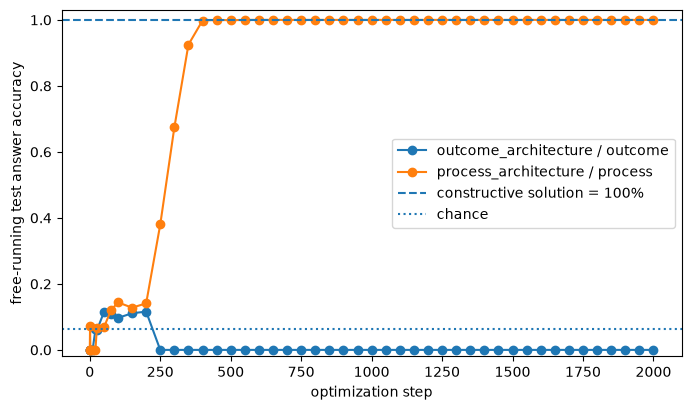

In [8]:

fig, ax = plt.subplots(figsize=(8, 4.5))

for (architecture, mode), frame in history.groupby(["architecture", "mode"]):
    ax.plot(
        frame["step"],
        frame["test_answer_accuracy"],
        marker="o",
        label=f"{architecture} / {mode}",
    )

ax.axhline(1.0, linestyle="--", label="constructive solution = 100%")
ax.axhline(1 / tokenizer.n_states, linestyle=":", label="chance")
ax.set_xlabel("optimization step")
ax.set_ylabel("free-running test answer accuracy")
ax.set_ylim(-0.02, 1.03)
ax.legend()
plt.show()


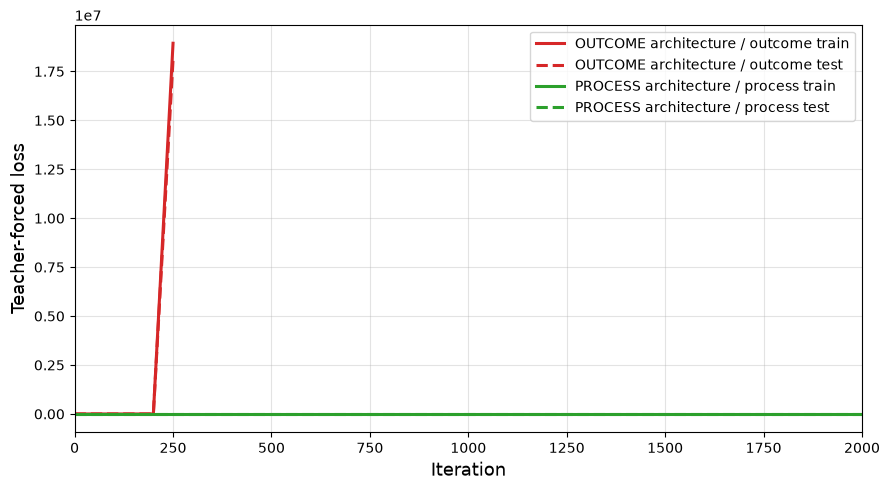

In [9]:
def plot_train_test_loss(history, *, steps=STEPS):
    required = {"architecture", "mode", "step", "train_loss", "test_loss"}
    missing = required.difference(history.columns)
    if missing:
        missing_text = ", ".join(sorted(missing))
        raise ValueError(f"history is missing required columns: {missing_text}")

    fig, ax = plt.subplots(figsize=(9, 5))
    styles = {
        ("process_architecture", "process"): {
            "color": "#2ca02c",
            "label": "PROCESS architecture / process",
        },
        ("outcome_architecture", "outcome"): {
            "color": "#d62728",
            "label": "OUTCOME architecture / outcome",
        },
    }

    for key, frame in history.sort_values("step").groupby(["architecture", "mode"]):
        style = styles.get(key, {"color": None, "label": " / ".join(map(str, key))})
        ax.plot(
            frame["step"],
            frame["train_loss"],
            color=style["color"],
            linewidth=2.2,
            label=f"{style['label']} train",
        )
        ax.plot(
            frame["step"],
            frame["test_loss"],
            color=style["color"],
            linestyle="--",
            linewidth=2.2,
            label=f"{style['label']} test",
        )

    ax.set_xlabel("Iteration", fontsize=13)
    ax.set_ylabel("Teacher-forced loss", fontsize=13)
    ax.set_xlim(0, steps)
    ax.grid(True, alpha=0.35)
    ax.legend(frameon=True, fontsize=10)
    fig.tight_layout()
    return fig, ax

plot_train_test_loss(history)
plt.show()



## 9. Inspect one free-running example

No gold continuation is fed to the model during this evaluation.


In [10]:

example_prompt = torch.tensor(
    [tokenizer.prompt(example)],
    dtype=torch.long,
    device=DEVICE,
)

for name, model, mode in [
    ("Fixed PROCESS", process_reference, "process"),
    ("Trained PROCESS", trained_process, "process"),
    ("Fixed OUTCOME", outcome_reference, "outcome"),
    ("Trained OUTCOME", trained_outcome, "outcome"),
]:
    budget = 3 if mode == "outcome" else 2 * DEPTH + 3
    generated = generate(
        model,
        example_prompt,
        budget,
        tokenizer.eos,
    )
    continuation = generated[0, example_prompt.shape[1]:]
    print(f"\n{name}")
    print(tokenizer.decode(continuation))



Fixed PROCESS
s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>

Trained PROCESS
s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>

Fixed OUTCOME
<COLON> S1001 <EOS>

Trained OUTCOME
S0000 S0000 S0000



## 10. How to interpret the result

There are four broad possibilities.

### Both trained models reach 100%

The two constructive solution classes are readily reachable from this initialization and optimizer.

### PROCESS reaches 100%, OUTCOME does not

Then

\[
\exists\theta^\star_{\rm O}:\operatorname{Err}(\theta^\star_{\rm O})=0
\]

but the tested terminal-supervision optimization trajectory does not discover it.

That is evidence for a **trainability / accessibility gap**, not an expressivity gap.

### OUTCOME reaches 100%, PROCESS does not

Then the existence of an explicit local process circuit does not by itself guarantee that ordinary trace training discovers it.

### Neither reaches 100%

Then constructive realizability and optimization reachability are substantially different for both architectures.

---

Do not infer an impossibility theorem from a failed run. Multiple seeds, learning-rate controls, and optimizer-stability diagnostics are needed before making a strong optimization claim.



# Optional appendix: full $2\times2$ architecture × supervision experiment

The primary notebook above trains exactly **two** models.

A separate, stronger control can cross:

$$
\{\text{PROCESS architecture},\text{OUTCOME architecture}\}
\times
\{\text{PROCESS supervision},\text{OUTCOME supervision}\}.
$$

That experiment trains **four** models and should be reported separately.

It requires the OUTCOME architecture to use the longer PROCESS position budget, so it is intentionally not the exact diagonal reachability experiment above.


In [11]:
RUN_OPTIONAL_2X2 = True

if RUN_OPTIONAL_2X2:
    from handcoded_utils import (
        build_random_trainable_outcome_architecture,
        build_random_trainable_process_architecture,
        run_architecture_experiment,
    )

    bases = {
        "process_architecture": build_random_trainable_process_architecture(
            tokenizer, DEPTH, seed=MODEL_SEED, device=DEVICE
        ),
        "outcome_architecture": build_random_trainable_outcome_architecture(
            tokenizer, DEPTH, seed=MODEL_SEED, device=DEVICE
        ),
    }

    models_2x2, history_2x2 = run_architecture_experiment(
        bases,
        training_data,
        batch_schedule,
        LR,
        CHECKPOINTS,
        train_eval,
        test_eval,
        tokenizer,
        circuit_prompts,
        test_loss_data=test_loss_data,
        loss_eval_size=LOSS_EVAL_SIZE,
    )

    display(history_2x2.drop(columns=["circuit_matrix"], errors="ignore"))
else:
    print("Skipping optional 2x2 experiment. Set RUN_OPTIONAL_2X2 = True to run it.")


architecture/mode:   0%|          | 0/4 [00:00<?, ?it/s]

architecture/mode: 100%|██████████| 4/4 [06:44<00:00, 101.18s/it]


,step,architecture,mode,train_loss,train_answer_accuracy_sample,test_answer_accuracy,test_exact_continuation,test_loss
0,0,process_architecture,outcome,4.277899,0.000000,0.000,0.000,4.278059
1,1,process_architecture,outcome,4.223452,0.000000,0.000,0.000,4.223055
2,2,process_architecture,outcome,4.143729,0.000000,0.000,0.000,4.142825
3,5,process_architecture,outcome,3.074750,0.000000,0.000,0.000,3.064029
4,10,process_architecture,outcome,1.842402,0.000000,0.000,0.000,1.821125
...,...,...,...,...,...,...,...,...
187,1800,outcome_architecture,process,0.029502,0.903333,0.914,0.911,0.028348
188,1850,outcome_architecture,process,0.018617,0.946667,0.971,0.970,0.008983
189,1900,outcome_architecture,process,0.030336,0.893333,0.917,0.912,0.013703
190,1950,outcome_architecture,process,0.005982,0.956667,0.963,0.962,0.013163
